1. modelo base
2. comparar CON/SIN outliers
3. tuning
4. mejor modelo
5. métricas
6. gráficas
7. guardar
8. comparación final con DT y RF

In [79]:
# Cargar Librerias

import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [80]:
# Cargar datasets procesados

X_train_CON_sel = pd.read_csv("../data/processed/X_train_CON_sel.csv")
X_test_CON_sel = pd.read_csv("../data/processed/X_test_CON_sel.csv")

X_train_SIN_sel = pd.read_csv("../data/processed/X_train_SIN_sel.csv")
X_test_SIN_sel = pd.read_csv("../data/processed/X_test_SIN_sel.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

## Probar un modelo base en ambas versiones

In [81]:
#Comparar ambas versiones

results = []

datasets = {
    "with_outliers": (X_train_CON_sel, X_test_CON_sel),
    "without_outliers": (X_train_SIN_sel, X_test_SIN_sel)
}

for name, (X_train, X_test) in datasets.items():
    model = XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    results.append({
        "dataset": name,
        "accuracy": acc
    })

results_df = pd.DataFrame(results).sort_values(by="accuracy", ascending=False)
print(results_df)

            dataset  accuracy
0     with_outliers  0.759740
1  without_outliers  0.753247


In [82]:
best_dataset_name = results_df.iloc[0]["dataset"]
print("Mejor dataset base:", best_dataset_name)

Mejor dataset base: with_outliers


In [83]:
if best_dataset_name == "CON_outliers":
    X_train = X_train_CON_sel
    X_test = X_test_CON_sel
else:
    X_train = X_train_SIN_sel
    X_test = X_test_SIN_sel

print(X_train.shape, X_test.shape)

(614, 6) (154, 6)


## Tuning con hiperparametros

In [84]:
results = []

n_estimators_list = [50, 100, 200]
learning_rate_list = [0.01, 0.1, 0.2]
max_depth_list = [3, 5, 7]

for n_estimators in n_estimators_list:
    for learning_rate in learning_rate_list:
        for max_depth in max_depth_list:
            model = XGBClassifier(
                n_estimators=n_estimators,
                learning_rate=learning_rate,
                max_depth=max_depth,
                random_state=42,
                eval_metric="logloss"
            )
            
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            
            results.append({
                "n_estimators": n_estimators,
                "learning_rate": learning_rate,
                "max_depth": max_depth,
                "accuracy": acc
            })

results_df = pd.DataFrame(results).sort_values(by="accuracy", ascending=False)
results_df.head(10)

,n_estimators,learning_rate,max_depth,accuracy
18,200,0.01,3,0.805195
9,100,0.01,3,0.792208
5,50,0.10,7,0.792208
19,200,0.01,5,0.785714
20,200,0.01,7,0.785714
12,100,0.10,3,0.785714
3,50,0.10,3,0.785714
4,50,0.10,5,0.779221
15,100,0.20,3,0.772727
14,100,0.10,7,0.772727


## Reentrenar el mejor modelo

In [85]:
best_row = results_df.iloc[0]

best_n_estimators = int(best_row["n_estimators"])
best_learning_rate = float(best_row["learning_rate"])
best_max_depth = int(best_row["max_depth"])

xgb_final = XGBClassifier(
    n_estimators=best_n_estimators,
    learning_rate=best_learning_rate,
    max_depth=best_max_depth,
    random_state=42,
    eval_metric="logloss"
)

xgb_final.fit(X_train, y_train)
y_pred = xgb_final.predict(X_test)

## Evaluar el modelo

In [86]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.8052


In [87]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86       100
           1       0.76      0.65      0.70        54

    accuracy                           0.81       154
   macro avg       0.79      0.77      0.78       154
weighted avg       0.80      0.81      0.80       154



## Sacar precision, recall, y f1 

In [88]:
report = classification_report(y_test, y_pred, output_dict=True)

prec = report["weighted avg"]["precision"]
rec = report["weighted avg"]["recall"]
f1 = report["weighted avg"]["f1-score"]

print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)

Precision: 0.8019114540853671
Recall: 0.8051948051948052
F1-score: 0.801148851148851


## Comprobar cual prdice mejor

In [89]:
report_df = pd.DataFrame(report).transpose()
report_df

,precision,recall,f1-score,support
0,0.824074,0.890000,0.855769,100.000000
1,0.760870,0.648148,0.700000,54.000000
accuracy,0.805195,0.805195,0.805195,0.805195
macro avg,0.792472,0.769074,0.777885,154.000000
weighted avg,0.801911,0.805195,0.801149,154.000000


In [90]:
report_df = pd.DataFrame(report).transpose()
report_df

,precision,recall,f1-score,support
0,0.824074,0.890000,0.855769,100.000000
1,0.760870,0.648148,0.700000,54.000000
accuracy,0.805195,0.805195,0.805195,0.805195
macro avg,0.792472,0.769074,0.777885,154.000000
weighted avg,0.801911,0.805195,0.801149,154.000000


In [91]:
class_metrics = report_df.loc[["0", "1"], ["precision", "recall", "f1-score"]]
class_metrics

,precision,recall,f1-score
0,0.824074,0.890000,0.855769
1,0.760870,0.648148,0.700000


In [92]:
best_precision_class = class_metrics["precision"].idxmax()
worst_precision_class = class_metrics["precision"].idxmin()

print("Clase con mayor precision:", best_precision_class)
print("Clase con menor precision:", worst_precision_class)

Clase con mayor precision: 0
Clase con menor precision: 1


## Visual

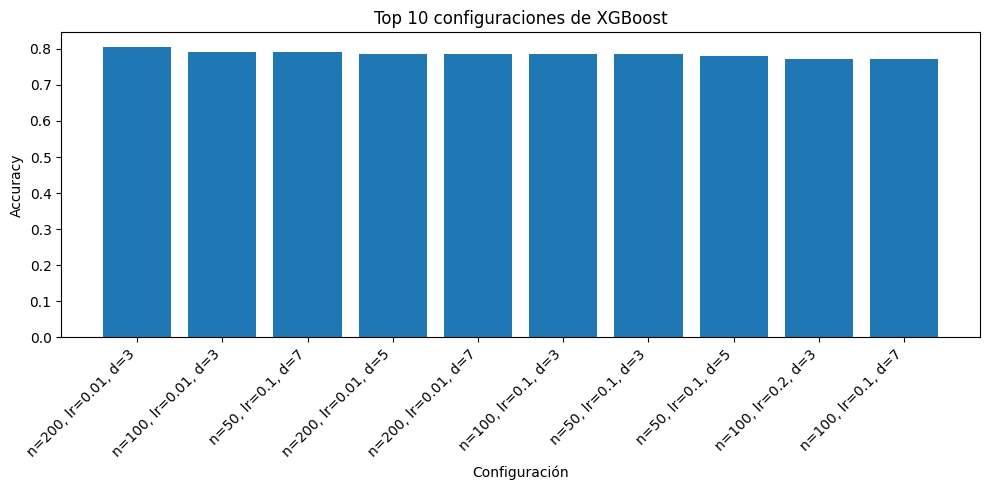

In [93]:
top10 = results_df.head(10).copy()
top10["config"] = (
    "n=" + top10["n_estimators"].astype(str) +
    ", lr=" + top10["learning_rate"].astype(str) +
    ", d=" + top10["max_depth"].astype(str)
)

plt.figure(figsize=(10, 5))
plt.bar(top10["config"], top10["accuracy"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 configuraciones de XGBoost")
plt.xlabel("Configuración")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

## Guardar modelo

In [94]:
os.makedirs("../models", exist_ok=True)

xgb_final.save_model("../models/xgboost_diabetes.json")

metadata = {
    "model": "XGBClassifier",
    "best_params": {
        "n_estimators": best_n_estimators,
        "learning_rate": best_learning_rate,
        "max_depth": best_max_depth,
        "random_state": 42
    },
    "metrics": {
        "accuracy": float(acc),
        "recall": float(rec),
        "precision": float(prec),
        "f1": float(f1)
    }
}

with open("../models/xgboost_diabetes_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("✅ Modelo guardado en ../models/xgboost_diabetes.json")
print("✅ Metadata guardada en ../models/xgboost_diabetes_metadata.json")

✅ Modelo guardado en ../models/xgboost_diabetes.json
✅ Metadata guardada en ../models/xgboost_diabetes_metadata.json


## Comparar con otros modelos

In [95]:
acc_tree = 0.6753
acc_rf = 0.7403   
acc_xgb = acc

comparison_df = pd.DataFrame({
    "Modelo": ["Decision Tree", "Random Forest", "XGBoost"],
    "Accuracy": [acc_tree, acc_rf, acc_xgb]
})

comparison_df

,Modelo,Accuracy
0,Decision Tree,0.675300
1,Random Forest,0.740300
2,XGBoost,0.805195
